# Regularization in Linear Regression

## Imported required libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.typing import ArrayLike, NDArray
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

%matplotlib inline

## Define a function to display evaluation metrics

<p>We'll be evaluating several models, so it's a good idea to make an evaluation function that includes the common metrics and explaned variances, etc.</p>

In [2]:
def regression_results(y_true: ArrayLike, y_pred: ArrayLike, regression_type: str) -> None:
    evs = explained_variance_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Evaluation metrics for {regression_type} Linear Regression")
    print(f"Explained Variance: {evs}")
    print(f"R²: {round(r2, 4)}")
    print(f"Mean Absolute Error: {mae}")
    print(f"Mean Squared Error: {mse}")
    print(f"Root Mean Squared Error: {np.sqrt(mse)}", end="\n\n")

## Generate a simple dataset with one feature

<p>We'll create a simple dataset with a linear relationship between the target and a single feature. We'll add some noise to the target to simulate real data. We'll also create a dataset from this one that has outliers added. Then you'll compare the three linear regression model performances on the two datasets, with and without significant outliers added.</p>

In [3]:
noise = 1
np.random.seed(42)
X: NDArray[np.float64] = 2 * np.random.rand(1000, 1)    # type: ignore
y: NDArray[np.float64] = 4 + 3 * X + noise * np.random.randn(1000, 1)   # type: ignore
y_ideal = 4 + 3 * X
y_outlier = pd.Series(y.reshape(-1).copy())

threshold = 1.5
outlier_indices = np.where(X.flatten() > threshold)[0]

num_outliers = 5
selected_indices: NDArray[np.int64] = np.random.choice(outlier_indices, num_outliers, replace=False)    # type: ignore

y_outlier[selected_indices] += np.random.uniform(50, 100, num_outliers)

## Plot the data with outliers and the ideal fit line

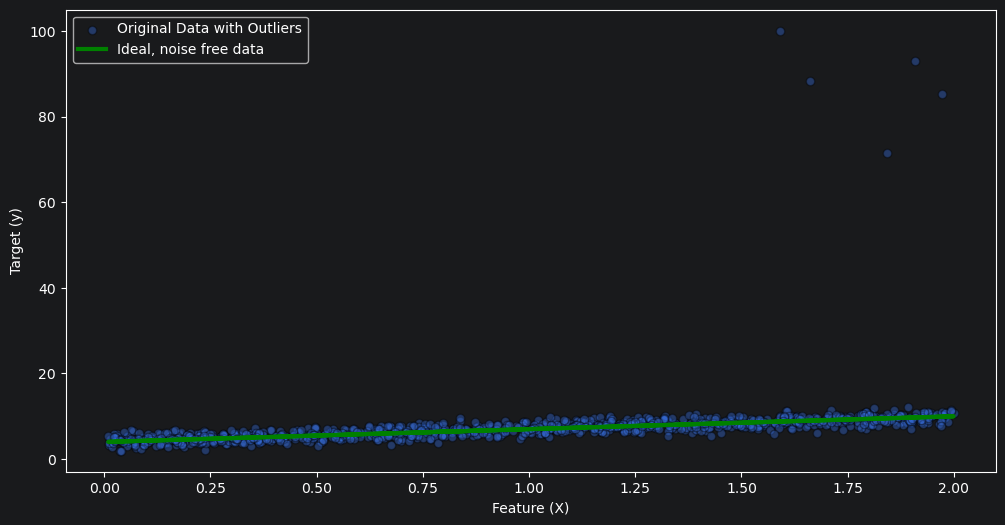

In [4]:
plt.figure(figsize=(12, 6))

plt.scatter(X, y_outlier, alpha=0.4, ec="k", label="Original Data with Outliers")
plt.plot(X, y_ideal, linewidth=3, color="g", label="Ideal, noise free data")

plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("")
plt.legend()

## Plot the data without outliers and the ideal fit line

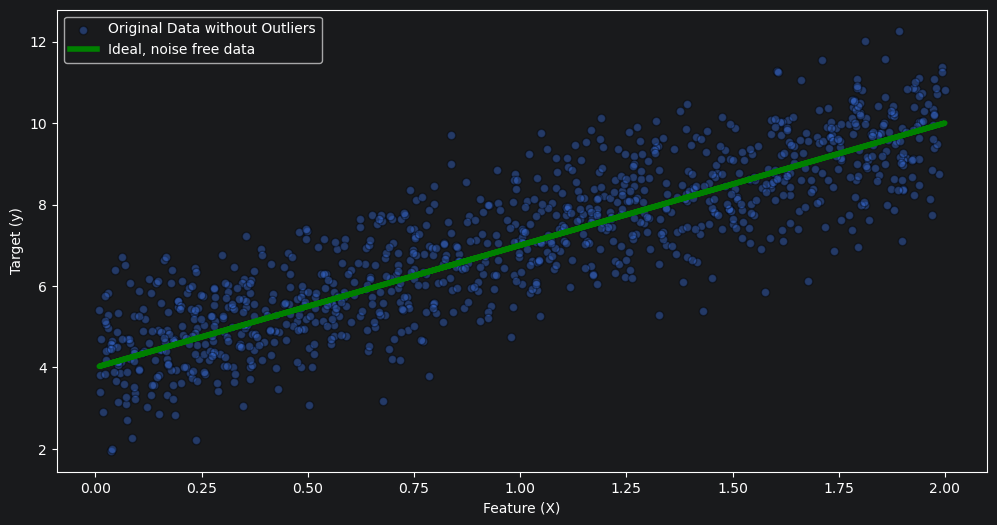

In [5]:
plt.figure(figsize=(12, 6))

plt.scatter(X, y, alpha=0.4, ec="k", label="Original Data without Outliers")
plt.plot(X, y_ideal, linewidth=4, color="g", label="Ideal, noise free data")

plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("")
plt.legend()

## Fit Ordinary, Ridge, and Lasso regression models and use them to make predictions on the outlier data

In [6]:
linear_reg1 = LinearRegression()
linear_reg1.fit(X, y_outlier)
y_outlier_pred_lin: NDArray[np.float64] = linear_reg1.predict(X)

ridge_reg1 = Ridge(alpha=1)
ridge_reg1.fit(X, y_outlier)
y_outlier_pred_ridge: NDArray[np.float64] = ridge_reg1.predict(X)

lasso_reg1 = Lasso(alpha=0.2)
lasso_reg1.fit(X, y_outlier)
y_outlier_pred_lasso: NDArray[np.float64] = lasso_reg1.predict(X)

## Print the regression results

In [7]:
regression_results(y, y_outlier_pred_lin, "Ordinary")
regression_results(y, y_outlier_pred_ridge, "Ridge")
regression_results(y, y_outlier_pred_lasso, "Lasso")

Evaluation metrics for Ordinary Linear Regression
Explained Variance: 0.6747726200397014
R²: 0.6357
Mean Absolute Error: 0.9467547013998349
Mean Squared Error: 1.41639411855287
Root Mean Squared Error: 1.190123572807828

Evaluation metrics for Ridge Linear Regression
Explained Variance: 0.6765780781437394
R²: 0.6375
Mean Absolute Error: 0.9443197402219141
Mean Squared Error: 1.4093745534226287
Root Mean Squared Error: 1.187170818973676

Evaluation metrics for Lasso Linear Regression
Explained Variance: 0.7393960494425802
R²: 0.7003
Mean Absolute Error: 0.8597148278978625
Mean Squared Error: 1.165140228684988
Root Mean Squared Error: 1.0794166149754172



<p>Judging from the low $R^2$ values, these are poor predictions.</p>

## Plot the data and the predictions for comparison

<p>Let's see how well the predictions match expected ideal values.</p>

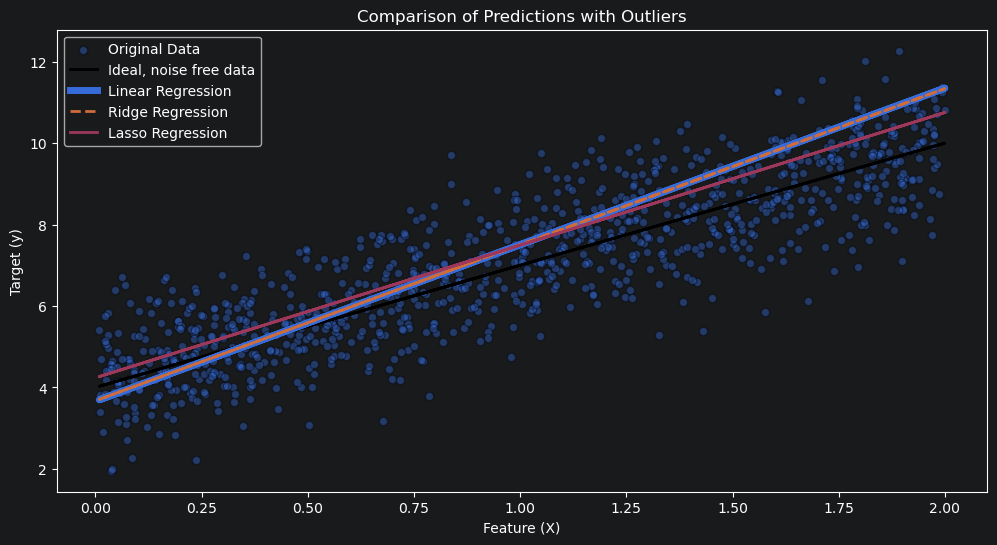

In [8]:
plt.figure(figsize=(12, 6))

plt.scatter(X, y, alpha=0.4, ec="k", label="Original Data")
plt.plot(X, y_ideal, linewidth=2, color="k", label="Ideal, noise free data")
plt.plot(X, y_outlier_pred_lin, linewidth=5, label="Linear Regression")
plt.plot(X, y_outlier_pred_ridge, linestyle="--", linewidth=2, label="Ridge Regression")
plt.plot(X, y_outlier_pred_lasso, linewidth=2, label="Lasso Regression")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Comparison of Predictions with Outliers")
plt.legend()

<p>As you can see, ordinary linear and ridge regression performed similarly, while Lasso outperformed both. Although the intercept is off for the Lasso fit line, it's slope is much closer to the ideal than the other fit lines. All three lines were <b>pulled up</b> by the outliers (not plotted here - compare to the plot above where the outliers are shown), with Lasso dampening that effect.</p>

## Build the models and the prediction plots from the same data, excluding the outliers

In [9]:
linear_reg2 = LinearRegression()
linear_reg2.fit(X, y)
y_pred_lin: NDArray[np.float64] = linear_reg2.predict(X)

ridge_reg2 = Ridge(alpha=1)
ridge_reg2.fit(X, y)
y_pred_ridge: NDArray[np.float64] = ridge_reg2.predict(X)

lasso_reg2 = Lasso(alpha=0.2)
lasso_reg2.fit(X, y)
y_pred_lasso: NDArray[np.float64] = lasso_reg2.predict(X)

In [10]:
regression_results(y, y_pred_lin, "Ordinary")
regression_results(y, y_pred_ridge, "Ridge")
regression_results(y, y_pred_lasso, "Lasso")

Evaluation metrics for Ordinary Linear Regression
Explained Variance: 0.7492346561823193
R²: 0.7492
Mean Absolute Error: 0.7872907216638584
Mean Squared Error: 0.9749678817794578
Root Mean Squared Error: 0.9874046190794622

Evaluation metrics for Ridge Linear Regression
Explained Variance: 0.7492282518288045
R²: 0.7492
Mean Absolute Error: 0.7874497786155008
Mean Squared Error: 0.9749927817073564
Root Mean Squared Error: 0.9874172277752482

Evaluation metrics for Lasso Linear Regression
Explained Variance: 0.7190672818378017
R²: 0.7191
Mean Absolute Error: 0.8407541239094678
Mean Squared Error: 1.0922576978909961
Root Mean Squared Error: 1.0451113327732104



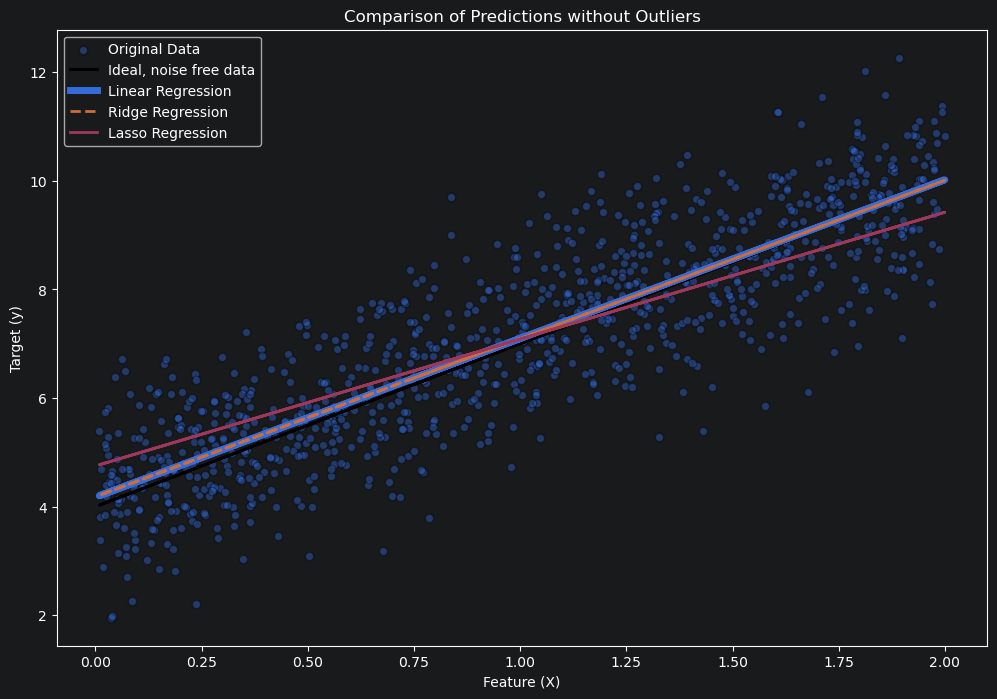

In [11]:
plt.figure(figsize=(12, 8))

plt.scatter(X, y, alpha=0.4, ec="k", label="Original Data")
plt.plot(X, y_ideal, linewidth=2, color="k", label="Ideal, noise free data")
plt.plot(X, y_pred_lin, linewidth=5, label="Linear Regression")
plt.plot(X, y_pred_ridge, linestyle="--", linewidth=2, label="Ridge Regression")
plt.plot(X, y_pred_lasso, linewidth=2, label="Lasso Regression")

plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.title("Comparison of Predictions without Outliers")
plt.legend()

## Multiple regression regularization and Lasso feature selection

<p>Now that you have explored regularization for simple, one-dimensional regression, let's take a deeper look at a multiple regression modelling scenario.</p>
<p>You'll again compare performances of the three linear regression methods and then use the Lasso result to select important features to use in another modelling pass.</p>

### Create a high dimensional synthetic dataset with a small number of informative features using `make_regression`

<p>The output of <code>make_regression</code> is generated by applying a random linear regression model based on <code>n_informative</code> nonzero regressors and some adjustable gaussian noise.</p>
<p>Along with the features and the target variable, the regression model coefficients can also be obtained from the output.</p>
<p>We'll split the data into training and testing sets, and also split the ideal predictions, which is a line based on the linear regression model.</p>

In [12]:
reg: tuple[NDArray[np.float64], ...] = make_regression(n_samples=100, n_features=100, n_informative=10, noise=10, random_state=42, coef=True)
X, y, ideal_coef = reg

ideal_predictions: NDArray[np.float64] = X @ ideal_coef # type: ignore

split_data: tuple[NDArray[np.float64], ...] = train_test_split(X, y, ideal_predictions, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test, ideal_train, ideal_test = split_data

### Initialize and fit the linear regression models and use them to predict the target

In [13]:
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)
linear = LinearRegression()

lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
linear.fit(X_train, y_train)

y_pred_linear = linear.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

### Print the regression results

In [14]:
regression_results(y_test, y_pred_linear, "Ordinary")
regression_results(y_test, y_pred_ridge, "Ridge")
regression_results(y_test, y_pred_lasso, "Lasso")

Evaluation metrics for Ordinary Linear Regression
Explained Variance: 0.43537627645711063
R²: 0.4018
Mean Absolute Error: 77.7353394916223
Mean Squared Error: 9844.271392426412
Root Mean Squared Error: 99.2183017009786

Evaluation metrics for Ridge Linear Regression
Explained Variance: 0.44461662505280575
R²: 0.4079
Mean Absolute Error: 76.96219411699008
Mean Squared Error: 9744.469337414595
Root Mean Squared Error: 98.71407871937313

Evaluation metrics for Lasso Linear Regression
Explained Variance: 0.9815391932664739
R²: 0.9815
Mean Absolute Error: 13.885532176159101
Mean Squared Error: 304.64404899421515
Root Mean Squared Error: 17.45405537387272



<p>The results for ordinary and ridge regression are poor. Explained variances are under 50%, and $R^2$ is very low. However, the result for Lasso is stellar.</p>

### Plot the predictions vs actual

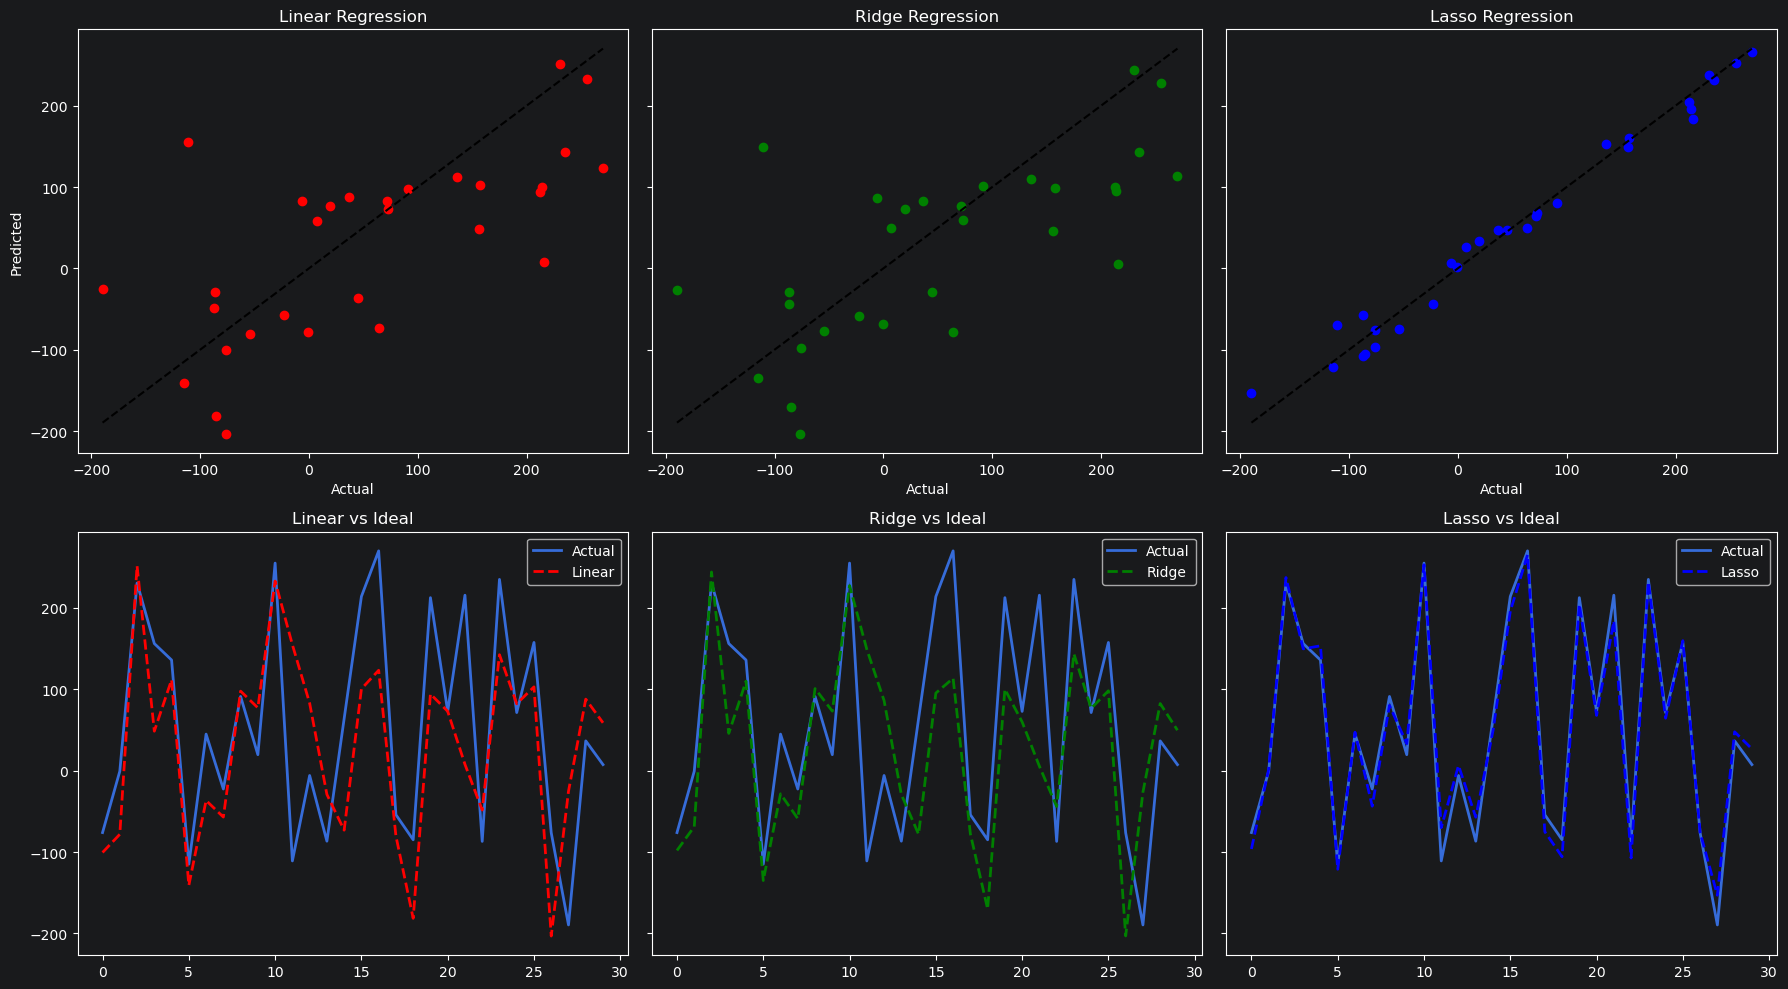

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

axes[0, 0].scatter(y_test, y_pred_linear, color="red", label="Linear")
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[0, 0].set_title("Linear Regression")
axes[0, 0].set_xlabel("Actual")
axes[0, 0].set_ylabel("Predicted")

axes[0, 1].scatter(y_test, y_pred_ridge, color="green", label="Ridge")
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0, 1].set_title("Ridge Regression")
axes[0, 1].set_xlabel("Actual")

axes[0, 2].scatter(y_test, y_pred_lasso, color="blue", label="Lasso")
axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0, 2].set_title("Lasso Regression")
axes[0, 2].set_xlabel("Actual")

axes[1, 0].plot(y_test, label="Actual", lw=2)
axes[1, 0].plot(y_pred_linear, "--", lw=2, color="red", label="Linear")
axes[1, 0].set_title("Linear vs Ideal")
axes[1, 0].legend()

axes[1, 1].plot(y_test, label="Actual", lw=2)
axes[1, 1].plot(y_pred_ridge, "--", lw=2, color="green", label="Ridge")
axes[1, 1].set_title("Ridge vs Ideal")
axes[1, 1].legend()

axes[1, 2].plot(y_test, label="Actual", lw=2)
axes[1, 2].plot(y_pred_lasso, "--", lw=2, color="blue", label="Lasso")
axes[1, 2].set_title("Lasso vs Ideal")
axes[1, 2].legend()

plt.tight_layout()

<p>You can see visually how much more the predictions deviate from the ideal target values for the ordinary and ridge regression results than for the Lasso result.</p>

## Model coefficients

In [16]:
linear_coef = linear.coef_
ridge_coef = ridge.coef_
lasso_coef = lasso.coef_

x_axis = np.arange(len(linear_coef))
x_labels = np.arange(min(x_axis), max(x_axis), 10)

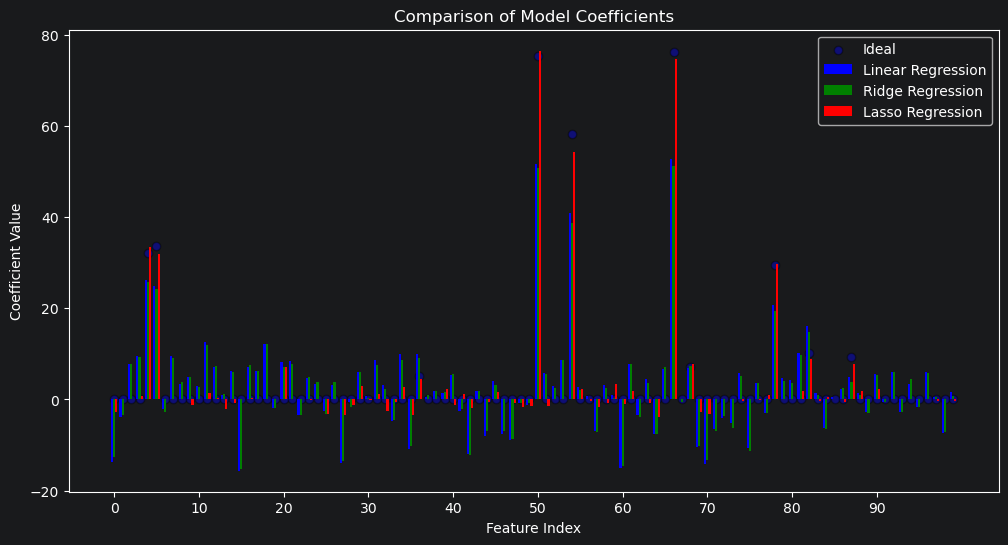

In [17]:
plt.figure(figsize=(12, 6))

plt.scatter(x_axis, ideal_coef, label="Ideal", color="blue", ec="k", alpha=0.4)
plt.bar(x_axis - 0.25, linear_coef, width=0.25, label="Linear Regression", color="blue")
plt.bar(x_axis, ridge_coef, width=0.25, label="Ridge Regression", color="green")
plt.bar(x_axis + 0.25, lasso_coef, width=0.25, label="Lasso Regression", color="red")

plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Comparison of Model Coefficients")
plt.xticks(x_labels)
plt.legend()

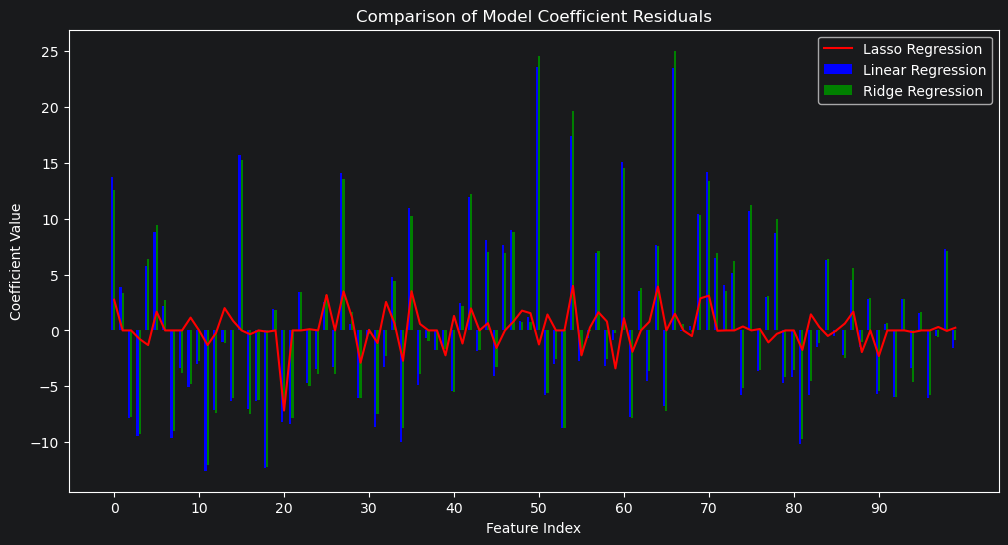

In [18]:
plt.figure(figsize=(12, 6))

plt.bar(x_axis - 0.25, ideal_coef - linear_coef, width=0.25, label="Linear Regression", color="blue")
plt.bar(x_axis, ideal_coef - ridge_coef, width=0.25, label="Ridge Regression", color="green")
plt.plot(x_axis, ideal_coef - lasso_coef, label="Lasso Regression", color="red")

plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Comparison of Model Coefficient Residuals")
plt.xticks(x_labels)
plt.legend()

<p>You can see from the first plot how much closer the Lasso coefficients are to the ideal coefficients than for the other two models. An easier way to visualize the difference is to look at the residual errors, as in the second plot. Clearly the Lasso coefficient residuals are much closer to zero than the others.</p>

### Use Lasso to select the most important features and compare the three different linear regression models again on the resulting data

#### Part 1. Choose a threshold value to select features based on the Lasso model coefficients

<p>Use the coefficient residual plot to select a reasonable threshold value, beyond which the Lasso coefficients are significant. To find a good threshold you can visually inspect the residuals plot and choose a value that distinguishes coefficients with larger than normal residuals.</p>
<p>Create a dataframe to compare the Lasso coefficients with the ideal coefficients, for the features selected with the Lasso coefficient threshold.</p>
<p>Include a boolean column that indicates whether the feature was selected as being important by the Lasso coefficient thresholding.</p>
<p>Display two filtered versions of the resulting dataframe:</p>
<ol>
    <li>Only those features identified as important by Lasso.</li>
    <li>Only the nonzero ideal coefficient indices.</li>
</ol>

In [19]:
threshold = 5

feature_importance_df = pd.DataFrame({
    "Lasso Coefficient": lasso_coef,
    "Ideal Coefficient": ideal_coef
})
feature_importance_df.loc[:, "Feature Selected"] = feature_importance_df.loc[:, "Lasso Coefficient"].abs() > threshold

In [20]:
print("Features Identified as Important by Lasso:")
feature_importance_df.loc[feature_importance_df.loc[:, "Feature Selected"], :]

Features Identified as Important by Lasso:


,Lasso Coefficient,Ideal Coefficient,Feature Selected
4,33.435088,32.125517,True
5,32.014793,33.692687,True
20,7.163636,0.000000,True
50,76.576829,75.319970,True
54,54.306360,58.286936,True
66,74.841971,76.330808,True
68,7.685653,7.180755,True
78,29.735685,29.434817,True
82,8.864669,10.301919,True
87,7.745131,9.427598,True


In [21]:
print("Nonzero Ideal Coefficient Indices:")
feature_importance_df.loc[feature_importance_df.loc[:, "Ideal Coefficient"] > 0, :]

Nonzero Ideal Coefficient Indices:


,Lasso Coefficient,Ideal Coefficient,Feature Selected
4,33.435088,32.125517,True
5,32.014793,33.692687,True
36,4.588118,5.166218,False
50,76.576829,75.319970,True
54,54.306360,58.286936,True
66,74.841971,76.330808,True
68,7.685653,7.180755,True
78,29.735685,29.434817,True
82,8.864669,10.301919,True
87,7.745131,9.427598,True


<p>The result is very good. We managed to correctly identify 9 out of the 10 important features.</p>

#### Part 2. Use the threshold to select the most important features for use in modeling

In [22]:
important_features = feature_importance_df.loc[feature_importance_df.loc[:, "Feature Selected"], :].index
X_filtered = X[:, important_features]

f"Shape of the filtered feature set: {X_filtered.shape}"

'Shape of the filtered feature set: (100, 10)'

In [23]:
split_data: tuple[NDArray[np.float64], ...] = train_test_split(X_filtered, y, ideal_predictions, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test, ideal_train, ideal_test = split_data

#### Part 3. Fit and apply the three models to the selected features

In [24]:
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)
linear = LinearRegression()

lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)
linear.fit(X_train, y_train)

y_pred_linear = linear.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

#### Part 4. Print the regression performance results

In [25]:
regression_results(y_test, y_pred_linear, "Ordinary")
regression_results(y_test, y_pred_ridge, "Ridge")
regression_results(y_test, y_pred_lasso, "Lasso")

Evaluation metrics for Ordinary Linear Regression
Explained Variance: 0.9917353616158148
R²: 0.9915
Mean Absolute Error: 9.652988552647365
Mean Squared Error: 139.48736260056114
Root Mean Squared Error: 11.810476815123137

Evaluation metrics for Ridge Linear Regression
Explained Variance: 0.9908593099849606
R²: 0.9905
Mean Absolute Error: 10.141835578025455
Mean Squared Error: 156.9034596066659
Root Mean Squared Error: 12.526111112658466

Evaluation metrics for Lasso Linear Regression
Explained Variance: 0.9916677448182657
R²: 0.9914
Mean Absolute Error: 9.692756406280674
Mean Squared Error: 140.80299775713905
Root Mean Squared Error: 11.86604389664639



<p>Let's compare the results to see the effect of feature selection using Lasso. Here are the previous results:</p>
<div>
    <div style="display: flex; flex-direction: column; align-items: center; gap: 8px; margin-bottom: 20px;">
        <span style="font-size: 16px; font-weight: bold;">Evaluation metrics for Ordinary Linear Regression</span>
        <table style="border-collapse: collapse;">
            <thead>
                <tr>
                    <th style="padding: 8px 12px; border: 1px solid;">Metric</th>
                    <th style="padding: 8px 12px; border: 1px solid;">Score</th>
                </tr>
            </thead>
            <tbody>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">explained_variance</td>
                <td style="padding: 8px 12px; border: 1px solid;">0.4354</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">R<sup>2</sup></td>
                <td style="padding: 8px 12px; border: 1px solid;">0.4018</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">MAE</td>
                <td style="padding: 8px 12px; border: 1px solid;">77.7353</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">MSE</td>
                <td style="padding: 8px 12px; border: 1px solid;">9844.2714</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">RMSE</td>
                <td style="padding: 8px 12px; border: 1px solid;">99.2183</td>
            </tr>
            </tbody>
        </table>
    </div>
    <div style="display: flex; flex-direction: column; align-items: center; gap: 8px; margin-bottom: 20px;">
        <span style="font-size: 16px; font-weight: bold;">Evaluation metrics for Ridge Linear Regression</span>
        <table style="border-collapse: collapse;">
            <thead>
            <tr>
                <th style="padding: 8px 12px; border: 1px solid;">Metric</th>
                <th style="padding: 8px 12px; border: 1px solid;">Score</th>
            </tr>
            </thead>
            <tbody>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">explained_variance</td>
                <td style="padding: 8px 12px; border: 1px solid;">0.4446</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">R<sup>2</sup></td>
                <td style="padding: 8px 12px; border: 1px solid;">0.4079</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">MAE</td>
                <td style="padding: 8px 12px; border: 1px solid;">76.9622</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">MSE</td>
                <td style="padding: 8px 12px; border: 1px solid;">9744.4693</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">RMSE</td>
                <td style="padding: 8px 12px; border: 1px solid;">98.7141</td>
            </tr>
            </tbody>
        </table>
    </div>
    <div style="display: flex; flex-direction: column; align-items: center; gap: 8px;">
        <span style="font-size: 16px; font-weight: bold;">Evaluation metrics for Lasso Linear Regression</span>
        <table style="border-collapse: collapse;">
            <thead>
            <tr>
                <th style="padding: 8px 12px; border: 1px solid;">Metric</th>
                <th style="padding: 8px 12px; border: 1px solid;">Score</th>
            </tr>
            </thead>
            <tbody>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">explained_variance</td>
                <td style="padding: 8px 12px; border: 1px solid;">0.9815</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">R<sup>2</sup></td>
                <td style="padding: 8px 12px; border: 1px solid;">0.9815</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">MAE</td>
                <td style="padding: 8px 12px; border: 1px solid;">13.8855</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">MSE</td>
                <td style="padding: 8px 12px; border: 1px solid;">304.644</td>
            </tr>
            <tr>
                <td style="padding: 8px 12px; border: 1px solid;">RMSE</td>
                <td style="padding: 8px 12px; border: 1px solid;">17.4541</td>
            </tr>
            </tbody>
        </table>
    </div>
</div>
<p>The new results are vastly improved for ordinary and Ridge regression, and slightly improved for Lasso, supporting the idea that <b>Lasso regression can be very beneficial when used as a feature selector</b>.</p>

#### Part 5. Regenerate the same plots as before and compare the results

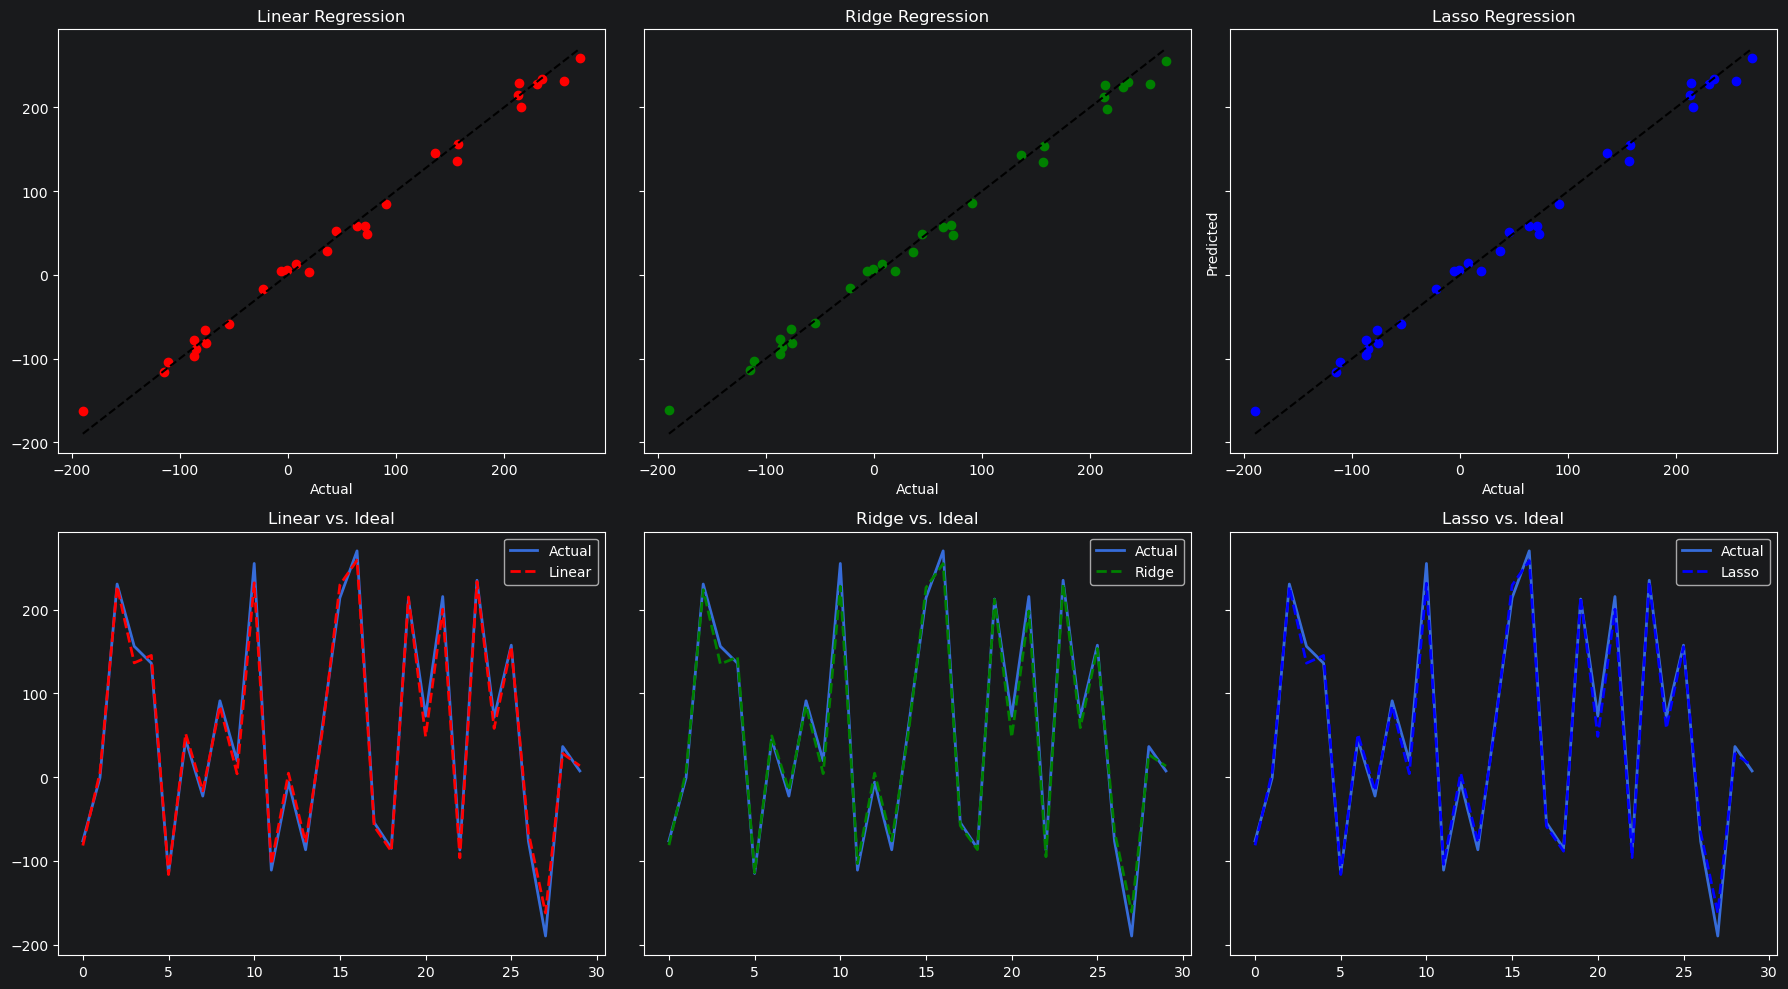

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

axes[0, 0].scatter(y_test, y_pred_linear, color="red", label="Linear")
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[0, 0].set_title("Linear Regression")
axes[0, 0].set_xlabel("Actual")

axes[0, 1].scatter(y_test, y_pred_ridge, color="green", label="Ridge")
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[0, 1].set_title("Ridge Regression")
axes[0, 1].set_xlabel("Actual")

axes[0, 2].scatter(y_test, y_pred_lasso, color="blue", label="Lasso")
axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
axes[0, 2].set_title("Lasso Regression")
axes[0, 2].set_xlabel("Actual")
axes[0, 2].set_ylabel("Predicted")

axes[1, 0].plot(y_test, label="Actual", lw=2)
axes[1, 0].plot(y_pred_linear, "--", lw=2, color="red", label="Linear")
axes[1, 0].set_title("Linear vs. Ideal")
axes[1, 0].legend()

axes[1, 1].plot(y_test, label="Actual", lw=2)
axes[1, 1].plot(y_pred_ridge, "--", lw=2, color="green", label="Ridge")
axes[1, 1].set_title("Ridge vs. Ideal")
axes[1, 1].legend()

axes[1, 2].plot(y_test, label="Actual", lw=2)
axes[1, 2].plot(y_pred_lasso, "--", lw=2, color="blue", label="Lasso")
axes[1, 2].set_title("Lasso vs. Ideal")
axes[1, 2].legend()

plt.tight_layout()

****
This is the end of the file.
****